# NYISO DART Spread Trading Strategy

---

## What this notebook covers

This notebook walks through the full strategy pipeline:

1. **Market background** — what DART is and why it matters
2. **Data** — 11 years of NYISO hourly prices, load forecasts, actuals
3. **Feature engineering** — the 50-dimensional feature vector
4. **Model** — zone-side logistic regressions (trained from scratch for LONGIL)
5. **Threshold tuning** — validation-set calibration per zone
6. **Backtest** — out-of-sample 2022–2025 results
7. **Statistics** — Sharpe, win rate, drawdown, precision/recall

**Feature convention**: DART lag features use the value exactly 24h and 48h  
before the operating hour (standard electricity-market time-series convention).

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# Project paths
PROJECT = Path(os.getcwd()).parent          # notebooks/ -> project root
DATA    = PROJECT / 'data'
MODELS  = PROJECT / 'models'
RESULTS = PROJECT / 'results'
FEATS   = DATA / 'features'

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Paper constants
GAMMA_POS = 5.0    # $/MWh — positive DART spike threshold
GAMMA_NEG = 30.0   # $/MWh — negative DART spike threshold
ZONES = ['CAPITL','CENTRL','DUNWOD','GENESE','HUDVL',
         'LONGIL','MHKVL','MILLWD','NORTH','NYC','WEST']

TRAIN_START, TRAIN_END = '2015-01-01', '2019-12-31'
VAL_START,   VAL_END   = '2020-01-01', '2021-12-31'
TEST_START,  TEST_END  = '2022-01-01', '2025-12-31'

print('Project root:', PROJECT)
print('Data dir exists:', DATA.exists())

Project root: c:\Users\Melvin Varghese\nyiso-dart-strategy
Data dir exists: True


---
## 1. Market background

### How NYISO electricity markets work

NYISO (New York Independent System Operator) clears electricity through a **two-settlement system**:

| Settlement | When cleared | What it prices |
|---|---|---|
| **Day-Ahead (DA)** | The evening before, results ~11am; gate closes **05:00 ET day D−1** | Forward price for each hour of operating day D |
| **Real-Time (RT)** | Every 5 minutes during actual operations | Actual physical imbalances |

### What is DART?

$$\text{DART}_{t,z} = \text{DA}_{t,z} - \text{RT}_{t,z}$$

- **DART > 0**: Day-ahead priced electricity *above* what real-time settled. If you sold DA and bought back RT (a **DEC** trade), you profited.
- **DART < 0**: Real-time was *more expensive* than DA. If you bought DA and sold back RT (an **INC** trade), you profited.

### INC/DEC virtual bids — the trading instrument

| Trade | Mechanic | Profit condition |
|---|---|---|
| **INC** (virtual demand) | Buy 1 MWh at DA price, auto-sold back at RT | RT > DA (DART < 0) |
| **DEC** (virtual supply) | Sell 1 MWh at DA price, auto-buy back at RT | DA > RT (DART > 0) |

These are **purely financial** — no electricity is actually delivered. NYISO settles both legs automatically.

### Why do large DART spikes exist?

The DA market clears based on **forecasts** of load and generator availability. When reality deviates:
- Hot summer afternoon → load higher than forecast → RT prices spike → negative DART
- Anticipated congestion clears in DA but doesn't materialize in RT → positive DART
- Generator outage unexpected in DA but real in RT → RT settles higher

These patterns have **autocorrelation** (forecast models are systematically wrong in similar conditions)
and **zonal structure** (Long Island is import-constrained and spikes differently than upstate zones).

In [3]:
# Load the full hourly panel (2015-2025)
panel = pd.read_parquet(DATA / 'processed' / 'panel.parquet')

print('Panel shape:', panel.shape)
print('Columns:', list(panel.columns))
print()
print('Date range:', panel['interval_start_local'].min(), 'to', panel['interval_start_local'].max())
print('Zones:', sorted(panel['zone'].unique()))
print('Hours per zone:', panel.groupby('zone').size().iloc[0])
print()
print('DART statistics across all zones and years:')
print(panel['dart'].describe().round(2).to_string())

Panel shape: (1052832, 16)
Columns: ['interval_start_utc', 'interval_start_local', 'zone', 'da_lmp', 'rt_lmp', 'dart', 'da_energy', 'da_loss', 'da_congestion', 'rt_energy', 'rt_loss', 'rt_congestion', 'actual_load', 'da_load_forecast', 'forecast_publish_time', 'load_forecast_error']

Date range: 2015-01-01 00:00:00-05:00 to 2025-12-31 23:00:00-05:00
Zones: ['CAPITL', 'CENTRL', 'DUNWOD', 'GENESE', 'HUDVL', 'LONGIL', 'MHKVL', 'MILLWD', 'NORTH', 'NYC', 'WEST']
Hours per zone: 95712

DART statistics across all zones and years:
count    1052832.00
mean           0.11
std           35.48
min        -4166.13
25%           -3.41
50%            1.65
75%            7.28
max         2488.08


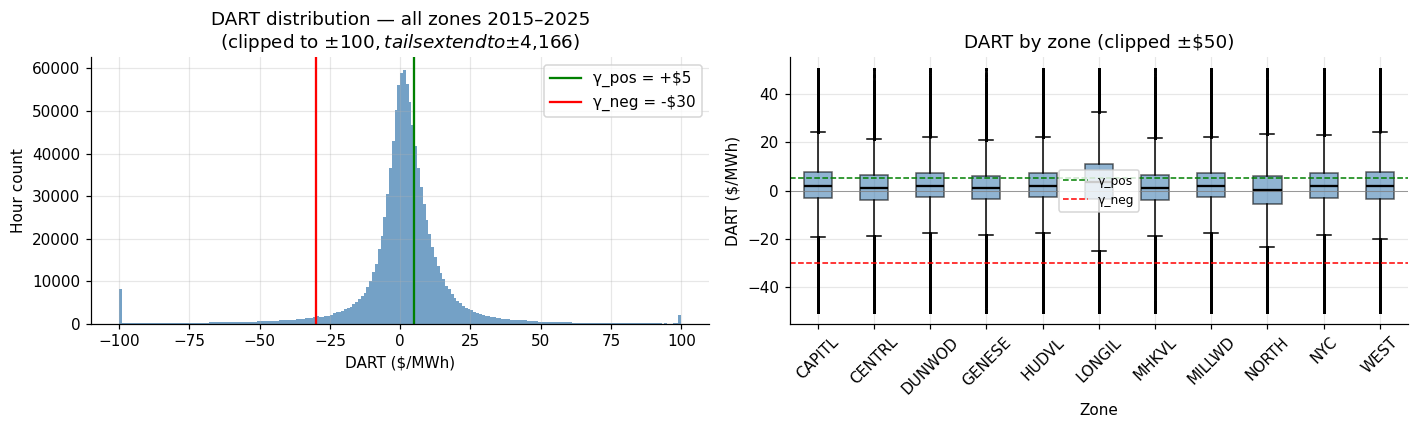

Spike prevalence across all zone-hours (2015–2025):
  Positive DART spike (≥ +$5.0): 33.4%
  Negative DART spike (≤ -$30.0): 3.9%
  Both are rare, especially the negative side — which is why recall is low


In [4]:
# ── DART distribution with spike thresholds ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: full histogram clipped to [-100, 100]
ax = axes[0]
dart = panel['dart'].clip(-100, 100)
ax.hist(dart, bins=200, color='steelblue', alpha=0.75, edgecolor='none')
ax.axvline( GAMMA_POS, color='green', lw=1.5, label=f'γ_pos = +${GAMMA_POS:.0f}')
ax.axvline(-GAMMA_NEG, color='red',   lw=1.5, label=f'γ_neg = -${GAMMA_NEG:.0f}')
ax.set_xlabel('DART ($/MWh)')
ax.set_ylabel('Hour count')
ax.set_title('DART distribution — all zones 2015–2025\n(clipped to ±$100, tails extend to ±$4,166)')
ax.legend()

# Right: DART by zone (box plot)
ax = axes[1]
zone_darts = [panel.loc[panel['zone']==z,'dart'].clip(-50,50).values for z in ZONES]
bp = ax.boxplot(zone_darts, labels=ZONES, patch_artist=True,
                medianprops=dict(color='black', lw=1.5),
                flierprops=dict(marker='.', ms=1, alpha=0.2))
for patch in bp['boxes']:
    patch.set_facecolor('steelblue'); patch.set_alpha(0.6)
ax.axhline(0, color='grey', lw=0.5)
ax.axhline( GAMMA_POS, color='green', lw=1, ls='--', label=f'γ_pos')
ax.axhline(-GAMMA_NEG, color='red',   lw=1, ls='--', label=f'γ_neg')
ax.set_xlabel('Zone'); ax.set_ylabel('DART ($/MWh)')
ax.set_title('DART by zone (clipped ±$50)')
ax.tick_params(axis='x', rotation=45); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Spike prevalence
print('Spike prevalence across all zone-hours (2015–2025):')
pos_rate = (panel['dart'] >= GAMMA_POS).mean()
neg_rate = (panel['dart'] <= -GAMMA_NEG).mean()
print(f'  Positive DART spike (≥ +${GAMMA_POS}): {pos_rate:.1%}')
print(f'  Negative DART spike (≤ -${GAMMA_NEG}): {neg_rate:.1%}')
print(f'  Both are rare, especially the negative side — which is why recall is low')

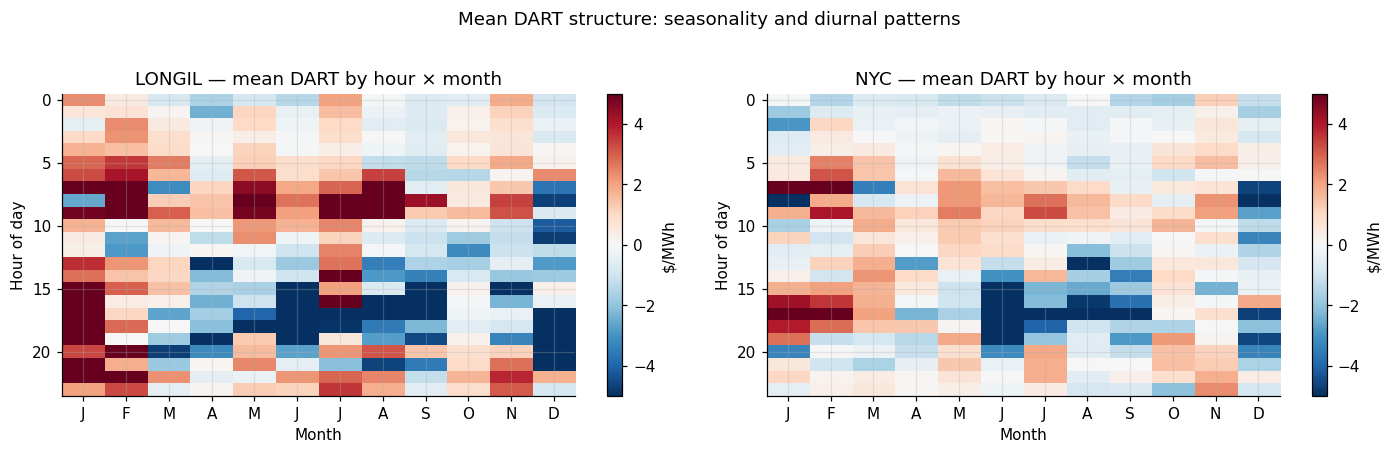

Observation: summer peak hours show large positive DART in LONGIL
(DA over-forecasts, RT settles lower — DEC opportunities)
NYC shows more negative DART in peak hours (congestion drives RT up)


In [5]:
# ── DART heatmaps: hour-of-day × month (LONGIL and NYC) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, zone in zip(axes, ['LONGIL', 'NYC']):
    z = panel[panel['zone'] == zone].copy()
    z['hour'] = z['interval_start_local'].dt.hour
    z['month'] = z['interval_start_local'].dt.month
    pivot = z.pivot_table(values='dart', index='hour', columns='month', aggfunc='mean')
    im = ax.imshow(pivot, aspect='auto', cmap='RdBu_r', vmin=-5, vmax=5)
    ax.set_xlabel('Month'); ax.set_ylabel('Hour of day')
    ax.set_title(f'{zone} — mean DART by hour × month')
    ax.set_xticks(range(12)); ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    plt.colorbar(im, ax=ax, label='$/MWh')

plt.suptitle('Mean DART structure: seasonality and diurnal patterns', y=1.02)
plt.tight_layout()
plt.show()

print('Observation: summer peak hours show large positive DART in LONGIL')
print('(DA over-forecasts, RT settles lower — DEC opportunities)')
print('NYC shows more negative DART in peak hours (congestion drives RT up)')

---
## 2. Feature engineering — the 50-dimensional vector

For each operating hour `t` on day D, we build a single feature vector at gate-closure time (05:00 ET on day D−1).

The vector is **global across all zones** — to predict LONGIL's spike at 18:00,  
we use LONGIL's *and every other zone's* features. This lets the model capture  
cross-zonal congestion propagation.

**Zone-level block (4 features × 11 zones = 44)**

| Feature | What it is | Why it predicts spikes |
|---|---|---|
| `z_da_load_forecast` | MW forecast for hour t in zone z (known before gate close) | High forecast → high system stress → higher spike risk |
| `z_dart_lag24` | DART at same hour, **exactly 24h earlier** (day D−1) | Autocorrelation: yesterday's spike predicts today's |
| `z_dart_lag48` | DART at same hour, exactly 48h earlier (day D−2) | Longer-range autocorrelation; independent signal |
| `z_lfe_lag24` | Load forecast error 24h ago (actual − forecast) | Systematic bias in NYISO forecasting model |

**Calendar block (6 features)**

| Feature | Captures |
|---|---|
| `hour_of_day` | Diurnal pattern (peak at 14:00-18:00, trough at 04:00) |
| `month_of_year` | Seasonal pattern |
| `is_winter`, `is_summer` | Season indicators (shoulder = reference) |
| `is_weekend` | Lower demand, different congestion patterns |
| `is_holiday` | Reduced industrial load |

**Total: 44 + 6 = 50 features**

In [ ]:
# Load the feature matrix (naive = literal t-24h lag, standard time-series convention)
X = pd.read_parquet(FEATS / 'X_naive.parquet')
y = pd.read_parquet(FEATS / 'y.parquet')

print(f'Feature matrix X: {X.shape[0]:,} hours × {X.shape[1]} features')
print(f'Label matrix   y: {y.shape[0]:,} hours × {y.shape[1]} labels')
print()
print('Column layout:')
print('  Zone-level features (first 22 of 44):')
for c in X.columns[:22]: print(f'    {c}')
print('  ...')
print('  Calendar features:')
for c in X.columns[-6:]: print(f'    {c}')

In [7]:
# ── Concrete example: the feature vector for a summer peak hour ───────────────
# Pick a summer peak hour with a big spike (2024-07-15 18:00)
target = pd.Timestamp('2024-07-15 18:00:00', tz='America/New_York')
candidates = X.index[X.index.year == 2024]
candidates = candidates[(candidates.month == 7) & (candidates.hour == 18)]
if len(candidates):
    t = candidates[10]  # pick mid-month
    row = X.loc[t]
    print(f'Feature vector for hour: {t}')
    print(f'Labels (pos/neg spikes at this hour):')
    for z in ['LONGIL', 'NYC', 'CAPITL']:
        print(f'  {z:8s}  pos={int(y.loc[t, z+"_pos"]):d}  neg={int(y.loc[t, z+"_neg"]):d}')
    print()
    # Show LONGIL's 4 features
    print('LONGIL features at this hour:')
    longil_feats = [c for c in X.columns if c.startswith('LONGIL')]
    print(row[longil_feats].to_string())
    print()
    print('Calendar features:')
    print(row[X.columns[-6:]].to_string())

Feature vector for hour: 2024-07-11 18:00:00-04:00
Labels (pos/neg spikes at this hour):
  LONGIL    pos=1  neg=0
  NYC       pos=1  neg=0
  CAPITL    pos=1  neg=0

LONGIL features at this hour:
LONGIL_da_load_forecast    4399.000000
LONGIL_dart_lag24           -24.010000
LONGIL_dart_lag48            58.870000
LONGIL_lfe_lag24            107.931471

Calendar features:
hour_of_day      18.0
month_of_year     7.0
is_winter         0.0
is_summer         1.0
is_weekend        0.0
is_holiday        0.0


---
## 3. Train / Validation / Test split

The split is locked by calendar date:

```
Train      2015-01-01 → 2019-12-31   (fit logistic regression coefficients)
Validation 2020-01-01 → 2021-12-31   (tune per-zone probability thresholds τ)
Test       2022-01-01 → 2025-12-31   (report all results — never touched during dev)
```

**Critical**: the test period is accessed exactly once — at the end — to produce the
numbers in this notebook. All model selection and threshold tuning happens on validation only.

In [8]:
# ── Split statistics and label prevalence ────────────────────────────────────
def mask(idx, start, end):
    s = pd.Timestamp(start, tz=idx.tz)
    e = pd.Timestamp(end,   tz=idx.tz) + pd.Timedelta(hours=23)
    return (idx >= s) & (idx <= e)

idx = X.index
tr_mask = mask(idx, TRAIN_START, TRAIN_END)
va_mask  = mask(idx, VAL_START,   VAL_END)
te_mask  = mask(idx, TEST_START,  TEST_END)

print(f"{'Period':12s} {'Hours':>8s} {'Fraction':>10s}")
print('-' * 34)
for name, m in [('Train', tr_mask), ('Validation', va_mask), ('Test', te_mask)]:
    print(f"{name:12s} {m.sum():>8,} {m.mean():>10.1%}")

print()
print('Label prevalence by split (positive DART spikes, γ_pos = $5):')
print(f"{'Zone':8s} {'Train_pos%':>12s} {'Val_pos%':>10s} {'Test_pos%':>10s} | "
      f"{'Train_neg%':>12s} {'Val_neg%':>10s} {'Test_neg%':>10s}")
print('-' * 90)
for z in ZONES:
    yp = y[z+'_pos']; yn = y[z+'_neg']
    print(f"{z:8s} "
          f"{yp[tr_mask].mean():>12.1%} {yp[va_mask].mean():>10.1%} {yp[te_mask].mean():>10.1%} | "
          f"{yn[tr_mask].mean():>12.1%} {yn[va_mask].mean():>10.1%} {yn[te_mask].mean():>10.1%}")

Period          Hours   Fraction
----------------------------------
Train          43,104      45.0%
Validation     17,544      18.3%
Test           35,064      36.6%

Label prevalence by split (positive DART spikes, γ_pos = $5):
Zone       Train_pos%   Val_pos%  Test_pos% |   Train_neg%   Val_neg%  Test_neg%
------------------------------------------------------------------------------------------
CAPITL          35.7%      28.5%      38.4% |         3.8%       3.3%       5.4%
CENTRL          31.3%      23.4%      31.9% |         3.0%       1.6%       4.0%
DUNWOD          36.1%      24.5%      36.0% |         3.4%       2.6%       4.5%
GENESE          30.6%      22.9%      32.1% |         2.9%       1.6%       3.8%
HUDVL           35.2%      24.3%      36.2% |         3.3%       2.3%       4.2%
LONGIL          45.9%      39.1%      43.6% |         5.7%       6.7%       7.0%
MHKVL           30.8%      23.4%      33.2% |         3.0%       1.7%       4.0%
MILLWD          35.8%      24.4

---
## 4. Building the logistic regression — LONGIL negative-spike model

We train **22 separate logistic regressions** — one per (zone, side).  
Here we train the LONGIL_neg model (predicting negative DART spikes = INC trades)
in full detail.

### The model

$$P(\text{spike at } t) = \sigma\left(\beta_0 + \sum_{i=1}^{50} \beta_i \cdot x_i(t)\right), 
\quad \sigma(u) = \frac{1}{1+e^{-u}}$$

**Training loss** — cross-entropy per zone:

$$\mathcal{L}(\beta) = -\sum_t \left[ y_t \log p_t + (1-y_t)\log(1-p_t) \right]$$

**Preprocessing**: standard-scale features (fit on train only) so the L2 penalty  
treats all features equally regardless of their natural units (MW vs $/MWh vs 0/1).

**Hyperparameters**: plain logistic regression with cross-entropy loss.  
sklearn defaults: L2 penalty, C=1.0, lbfgs solver.

In [9]:
# ── Train LONGIL_neg from scratch ────────────────────────────────────────────
SHOWCASE = ('LONGIL', 'neg')
zone, side = SHOWCASE
label = f'{zone}_{side}'

# Select train rows with no NaN features or labels
y_label = y[label]
valid_rows = tr_mask & X.notna().all(axis=1) & y_label.notna()
X_tr = X[valid_rows].values
y_tr = y_label[valid_rows].astype(int).values

# Validation rows
va_valid = va_mask & X.notna().all(axis=1) & y_label.notna()
X_va = X[va_valid].values
y_va = y_label[va_valid].astype(int).values

print(f'Training {label}...')
print(f'  Train rows: {len(X_tr):,}  (positive class: {y_tr.sum():,} = {y_tr.mean():.1%})')
print(f'  Val   rows: {len(X_va):,}  (positive class: {y_va.sum():,} = {y_va.mean():.1%})')
print()

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                                  max_iter=1000, class_weight=None))
])
pipe.fit(X_tr, y_tr)

# In-sample and val performance
p_tr = pipe.predict_proba(X_tr)[:, 1]
p_va = pipe.predict_proba(X_va)[:, 1]

print('Model trained. Solver converged.')
print(f'  Mean predicted prob (train): {p_tr.mean():.4f}  (base rate: {y_tr.mean():.4f})')
print(f'  Mean predicted prob (val):   {p_va.mean():.4f}  (base rate: {y_va.mean():.4f})')

Training LONGIL_neg...
  Train rows: 42,412  (positive class: 2,444 = 5.8%)
  Val   rows: 17,368  (positive class: 1,159 = 6.7%)

Model trained. Solver converged.
  Mean predicted prob (train): 0.0577  (base rate: 0.0576)
  Mean predicted prob (val):   0.0490  (base rate: 0.0667)


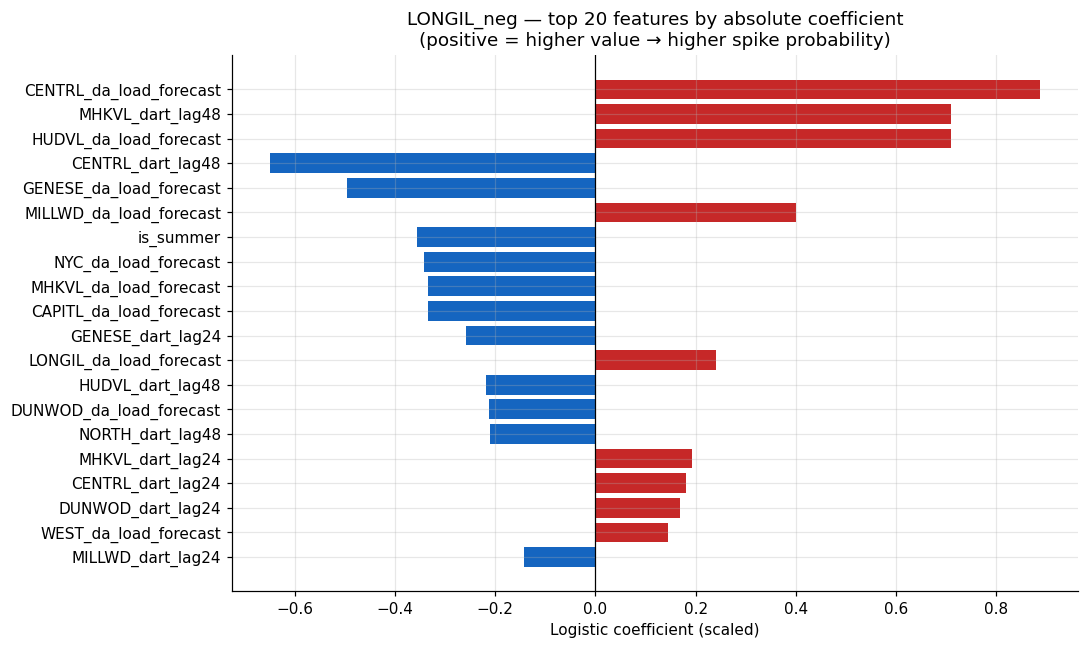

Top positive drivers (increase INC spike probability):
  CENTRL_da_load_forecast              +0.8860
  MHKVL_dart_lag48                     +0.7103
  HUDVL_da_load_forecast               +0.7094
  MILLWD_da_load_forecast              +0.4007
  LONGIL_da_load_forecast              +0.2412
Top negative drivers (decrease INC spike probability):
  CENTRL_dart_lag48                    -0.6487
  GENESE_da_load_forecast              -0.4956
  is_summer                            -0.3552
  NYC_da_load_forecast                 -0.3416
  MHKVL_da_load_forecast               -0.3349


In [10]:
# ── Coefficient plot: what did the model learn? ───────────────────────────────
coef = pipe.named_steps['logreg'].coef_[0]
coef_df = pd.DataFrame({'feature': X.columns, 'coef': coef})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(10, 6))
top = coef_df.head(20)
colors = ['#c62828' if c > 0 else '#1565c0' for c in top['coef']]
ax.barh(top['feature'][::-1], top['coef'][::-1], color=colors[::-1])
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Logistic coefficient (scaled)')
ax.set_title(f'{label} — top 20 features by absolute coefficient\n'
             '(positive = higher value → higher spike probability)')
plt.tight_layout()
plt.show()

print('Top positive drivers (increase INC spike probability):')
for _, r in coef_df[coef_df['coef'] > 0].head(5).iterrows():
    print(f'  {r["feature"]:35s}  {r["coef"]:+.4f}')
print('Top negative drivers (decrease INC spike probability):')
for _, r in coef_df[coef_df['coef'] < 0].head(5).iterrows():
    print(f'  {r["feature"]:35s}  {r["coef"]:+.4f}')

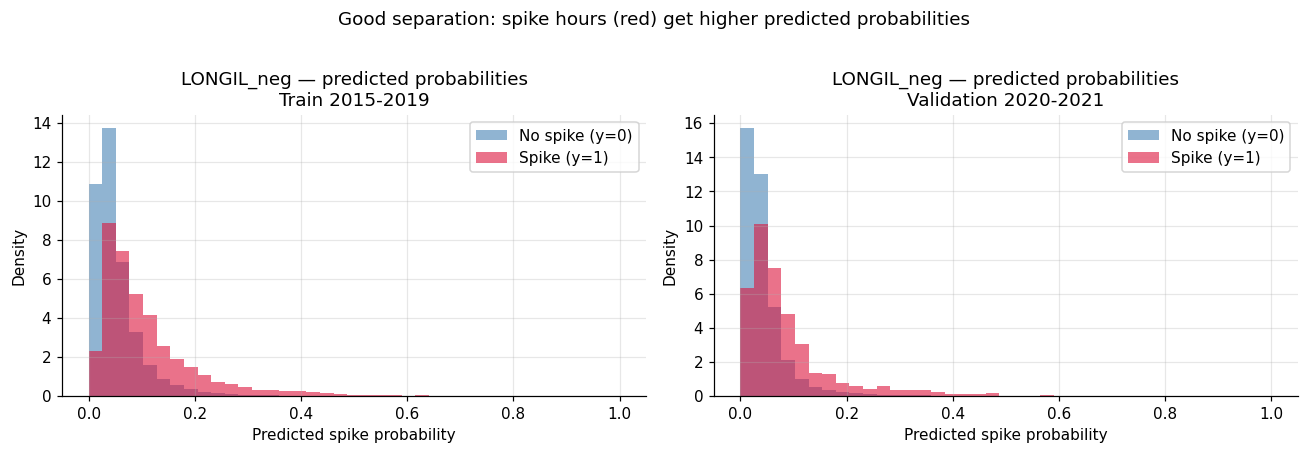

The model assigns higher probabilities to actual spike hours — that is the signal.
But distributions heavily overlap → we only trade the HIGH-confidence tail (p ≥ τ).


In [11]:
# ── Predicted probability distributions: positives vs negatives ───────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (proba, y_true, period) in zip(axes, [
    (p_tr, y_tr, 'Train 2015-2019'),
    (p_va, y_va, 'Validation 2020-2021')
]):
    bins = np.linspace(0, 1, 40)
    ax.hist(proba[y_true == 0], bins=bins, alpha=0.6, color='steelblue', label='No spike (y=0)', density=True)
    ax.hist(proba[y_true == 1], bins=bins, alpha=0.6, color='crimson',   label='Spike (y=1)',    density=True)
    ax.set_xlabel('Predicted spike probability')
    ax.set_ylabel('Density')
    ax.set_title(f'{label} — predicted probabilities\n{period}')
    ax.legend()

plt.suptitle('Good separation: spike hours (red) get higher predicted probabilities', y=1.02)
plt.tight_layout()
plt.show()

print('The model assigns higher probabilities to actual spike hours — that is the signal.')
print('But distributions heavily overlap → we only trade the HIGH-confidence tail (p ≥ τ).')

---
## 5. Threshold tuning — finding the right probability cutoff

A logistic regression gives us $p_t \in [0,1]$. We only trade when $p_t \geq \tau$.  
Setting $\tau$ too low: too many trades, many wrong; **precision drops**.  
Setting $\tau$ too high: very few trades, but mostly correct; **recall drops**.  

We tune $\tau$ per zone on the validation set (2020–2021) to **maximise unit-size P&L**:

$$\tau^* = \arg\max_{\tau \in [0.5, 0.99]} \sum_{t: p_t \geq \tau} \text{payoff}(t)$$

Crucially: this sweep uses **only validation data**. The test set is never consulted.

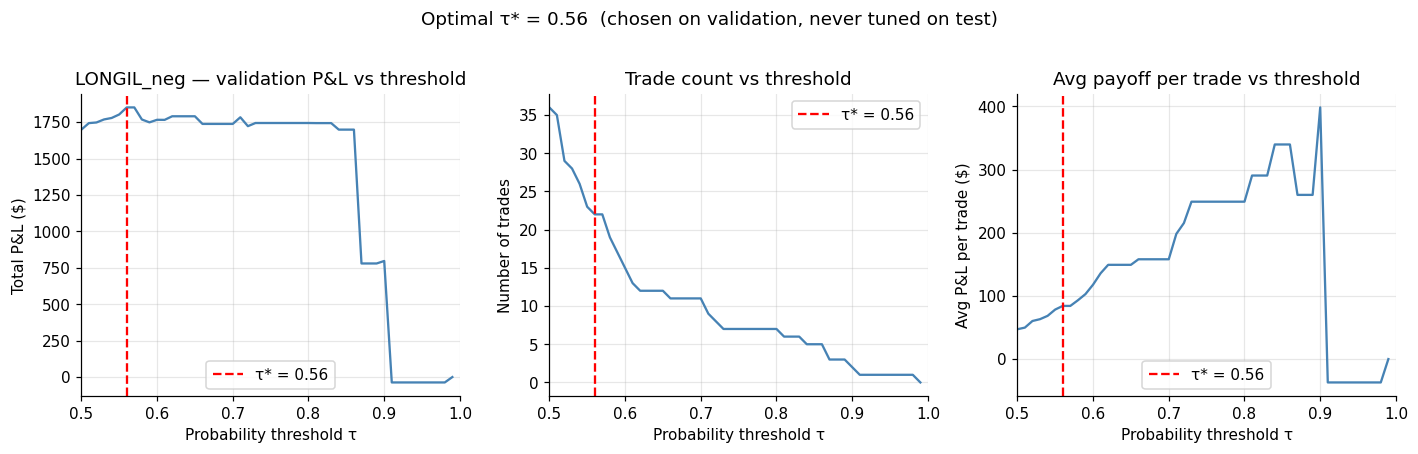

Optimal threshold: τ* = 0.56
  Validation trades: 22
  Validation total P&L: $1,851.05
  Validation avg P&L/trade: $84.14


In [12]:
# ── P&L vs τ curve on validation (LONGIL_neg) ─────────────────────────────────
dart_wide = panel.pivot(index='interval_start_local', columns='zone', values='dart')[ZONES]
dart_longil_va = dart_wide.loc[va_valid, 'LONGIL']

taus = np.round(np.arange(0.50, 1.00, 0.01), 2)
results = []
for tau in taus:
    triggered = p_va >= tau
    if triggered.sum() == 0:
        results.append((tau, 0, 0, 0))
        continue
    payoffs = -dart_longil_va.values[triggered]   # INC payoff = -DART
    results.append((tau, payoffs.sum(), triggered.sum(), payoffs.mean()))

res_df = pd.DataFrame(results, columns=['tau', 'total_pnl', 'n_trades', 'avg_pnl'])
best_tau = res_df.loc[res_df['total_pnl'].idxmax(), 'tau']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, label_y in zip(axes,
    ['total_pnl',  'n_trades', 'avg_pnl'],
    ['Total P&L ($)', 'Number of trades', 'Avg P&L per trade ($)']):
    ax.plot(res_df['tau'], res_df[col], lw=1.5, color='steelblue')
    ax.axvline(best_tau, color='red', lw=1.5, ls='--', label=f'τ* = {best_tau:.2f}')
    ax.set_xlabel('Probability threshold τ')
    ax.set_ylabel(label_y)
    ax.legend(); ax.set_xlim(0.5, 1.0)

axes[0].set_title(f'LONGIL_neg — validation P&L vs threshold')
axes[1].set_title('Trade count vs threshold')
axes[2].set_title('Avg payoff per trade vs threshold')
plt.suptitle(f'Optimal τ* = {best_tau:.2f}  (chosen on validation, never tuned on test)', y=1.02)
plt.tight_layout()
plt.show()

row = res_df.loc[res_df['tau'] == best_tau].iloc[0]
print(f'Optimal threshold: τ* = {best_tau:.2f}')
print(f'  Validation trades: {int(row.n_trades)}')
print(f'  Validation total P&L: ${row.total_pnl:,.2f}')
print(f'  Validation avg P&L/trade: ${row.avg_pnl:,.2f}')

In [ ]:
# ── Zone eligibility table — loaded from pre-computed tuning results ──────────
# Zones with negative validation P&L are excluded from trading on the test period.
thr = pd.read_parquet(MODELS / 'thresholds_naive.parquet')

print('Validation-tuned thresholds (ALL zones, naive features):')
print(f"{'Zone':8s} {'Side':5s} {'τ*':>6s} {'Val P&L':>12s} {'Trades':>8s} {'Avg/trade':>10s} {'Eligible':>10s}")
print('-' * 70)

for _, row in thr.sort_values(['side','val_pnl'], ascending=[True, False]).iterrows():
    tau_str = f"{row.best_tau:.2f}" if pd.notna(row.best_tau) else '  —  '
    elig_str = 'YES' if row.eligible else 'NO'
    print(f"{row.zone:8s} {row.side:5s} {tau_str:>6s} "
          f"${row.val_pnl:>10,.2f} {int(row.val_trades):>8d} "
          f"${row.val_avg:>8,.2f}   {elig_str:>5s}")

n_elig = thr['eligible'].sum()
print(f'\nEligible (zone, side) pairs: {n_elig}/22')
print("Ineligible pairs generate no trades in the test period.")

---
## 6. Out-of-sample backtest — Test period 2022–2025

We now apply the fixed policy (fitted models + chosen thresholds + eligibility mask)  
to the test period. **Nothing is re-estimated here** — this is the honest P&L.

Unit-size trading: **1 MWh per triggered signal** (the benchmark; can be scaled  
later with explicit position sizing and market-impact modelling).

### P&L per trade

$$\Pi^{\text{DEC}}_{t,z} = +\text{DART}_{t,z} \quad \text{(trade when pos spike predicted)}$$
$$\Pi^{\text{INC}}_{t,z} = -\text{DART}_{t,z} \quad \text{(trade when neg spike predicted)}$$

In [14]:
# Load pre-computed test trades (from nyiso_dart.backtest.run)
trades = pd.read_parquet(RESULTS / 'naive' / 'trades.parquet')

print(f'Total executed trades: {len(trades):,}')
print(f'Test period: {trades["interval_start_local"].min().date()} to '
             f'{trades["interval_start_local"].max().date()}')
print()
print('Trades by side:')
print(trades.groupby('side')[['payoff']].agg(['count','sum','mean']).round(2).to_string())
print()
print('Trades by year:')
print(trades.groupby('year')[['payoff']].agg(['count','sum']).round(0).to_string())

Total executed trades: 9,244
Test period: 2022-01-06 to 2025-12-17

Trades by side:
     payoff                  
      count       sum    mean
side                         
neg      93   21292.8  228.95
pos    9151  119010.2   13.01

Trades by year:
     payoff         
      count      sum
year                
2022   2422  39067.0
2023   1143  15633.0
2024   1633  32543.0
2025   4046  53061.0


In [ ]:
# ── Cumulative P&L curve ──────────────────────────────────────────────────────
cum = pd.read_parquet(RESULTS / 'naive' / 'cumulative_pnl.parquet')

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax = axes[0]
ax.plot(cum.index, cum['pnl_total'], lw=1.6, color='#1f4e79', label='Total')
ax.fill_between(cum.index, 0, cum['pnl_total'],
                where=cum['pnl_total'] >= 0, alpha=0.08, color='#1f4e79')
ax.axhline(0, color='grey', lw=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_ylabel('Cumulative P&L (USD)')
ax.set_title('Total cumulative P&L — unit size (1 MWh/trade)')
ax.legend()

ax = axes[1]
ax.plot(cum.index, cum['pnl_pos'], lw=1.2, color='#2e7d32', label='DEC (pos side)')
ax.plot(cum.index, cum['pnl_neg'], lw=1.2, color='#c62828', label='INC (neg side)')
ax.axhline(0, color='grey', lw=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_ylabel('Cumulative P&L (USD)')
ax.set_xlabel('Operating hour')
ax.set_title('DEC vs INC side attribution')
ax.legend()

plt.tight_layout()
plt.show()

total_pnl = float(cum['pnl_total'].iloc[-1])
print(f'Total P&L 2022-2025: ${total_pnl:,.2f}')
print(f'Annualized:          ${total_pnl/4:,.2f}')

In [ ]:
# ── Per-zone attribution ──────────────────────────────────────────────────────
zs = pd.read_parquet(RESULTS / 'naive' / 'zone_summary.parquet')
zs = zs.sort_values('total_pnl', ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
labels_bar = zs['zone'] + '/' + zs['side']
colors = ['#2e7d32' if s == 'pos' else '#c62828' for s in zs['side']]
bars = ax.barh(labels_bar[::-1], zs['total_pnl'][::-1] / 1000, color=colors[::-1])
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Total P&L (USD thousands, 2022-2025)')
ax.set_title('Per-(zone, side) P&L attribution\nGreen = DEC trade (pos side)  Red = INC trade (neg side)')
plt.tight_layout()
plt.show()

print('Full attribution table:')
print(f"{'Zone':8s} {'Side':5s} {'Trades':>8s} {'Precision':>10s} {'Total P&L':>12s} {'Avg/trade':>10s}")
print('-' * 60)
for _, r in zs.iterrows():
    print(f"{r.zone:8s} {r.side:5s} {r.n_trades:>8,.0f} {r.precision:>10.1%} "
          f"${r.total_pnl:>10,.2f} ${r.avg_pnl:>8,.2f}")

In [ ]:
# ── Yearly P&L breakdown ──────────────────────────────────────────────────────
yearly = trades.groupby(['zone','side','year'])['payoff'].sum().unstack('year').fillna(0)
yearly['TOTAL'] = yearly.sum(axis=1)
yearly = yearly.sort_values('TOTAL', ascending=False)

print('Yearly P&L by (zone, side) — test period 2022-2025:')
print(yearly.to_string(float_format=lambda x: f'${x:>9,.0f}'))

print()
print('Annual totals:')
annual = trades.groupby('year')['payoff'].agg(['sum','count']).rename(columns={'sum':'P&L','count':'Trades'})
print(annual.to_string(float_format=lambda x: f'${x:>10,.2f}'))

---
## 7. Precision and recall analysis

The strategy is deliberately **selective** — it does not try to catch every spike.
It trades only when the model is highly confident, accepting **low recall** in exchange  
for **high precision**.

| Metric | Definition | What we want |
|---|---|---|
| **Precision** | (correct predictions) / (all predictions) | High → few wasted trades |
| **Recall** | (correct predictions) / (all actual spikes) | Low is OK — we only need a few good signals |

The trade-off is intentional: with rare-event labels (spikes are 2–6% of hours for the
neg side), trying to maximise recall would mean trading constantly and drowning the
predictive signal in noise.

In [ ]:
# ── Precision / recall table ──────────────────────────────────────────────────
pr = pd.read_csv(RESULTS / 'naive' / 'precision_recall.csv')
pr = pr[pr['eligible'] == True].sort_values('precision', ascending=False)

print('Precision / Recall — test period 2022-2025 (eligible zones only)')
print(f"{'Zone':8s} {'Side':5s} {'τ':>5s} {'Prec':>8s} {'Recall':>8s} {'F1':>6s} "
      f"{'TP':>6s} {'FP':>6s} {'Support':>8s}")
print('-' * 70)

for _, r in pr.iterrows():
    if pd.isna(r['precision']): continue
    print(f"{r.zone:8s} {r.side:5s} {r.tau:>5.2f} {r.precision:>8.3f} "
          f"{r.recall:>8.4f} {r.f1:>6.3f} {r.TP:>6.0f} {r.FP:>6.0f} {r.support_pos:>8.0f}")

print()
pos_prec = pr[pr['side']=='pos']['precision'].mean()
neg_prec = pr[pr['side']=='neg']['precision'].dropna().mean()
print(f'Average DEC precision: {pos_prec:.1%}')
print(f'Average INC precision: {neg_prec:.1%}')
print()
print('The asymmetry between DEC and INC precision is structural: DEC spikes')
print('(positive DART) are more common and more autocorrelated than INC spikes')
print('(negative DART, which depend on rare RT supply shocks).')

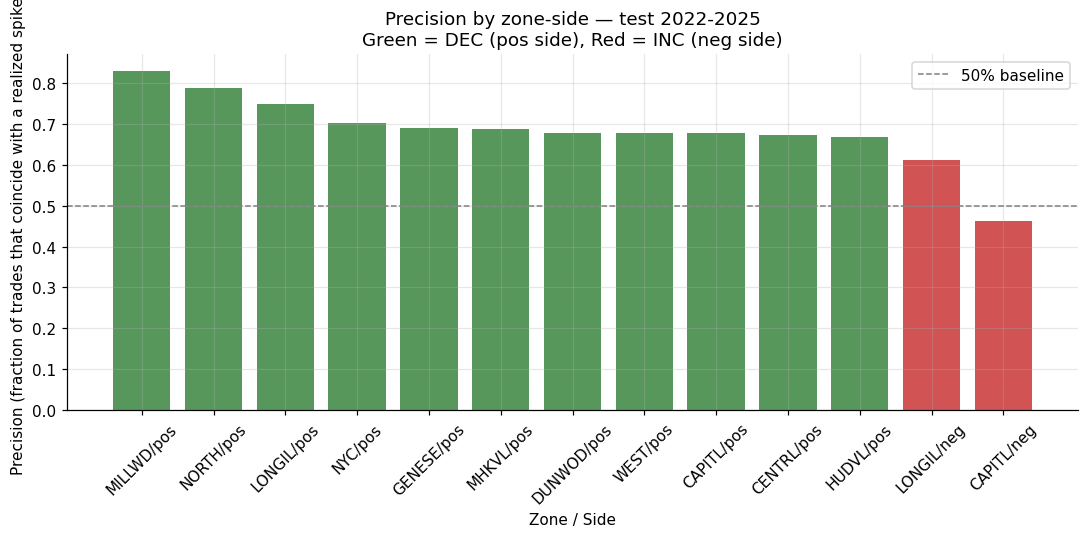

In [19]:
# ── Precision by zone-side (bar chart) ────────────────────────────────────────
pr_plot = pr[pr['eligible'] == True].dropna(subset=['precision'])
pr_plot['label'] = pr_plot['zone'] + '/' + pr_plot['side']
pr_plot = pr_plot.sort_values('precision', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2e7d32' if s == 'pos' else '#c62828' for s in pr_plot['side']]
ax.bar(pr_plot['label'], pr_plot['precision'], color=colors, alpha=0.8)
ax.axhline(0.5, color='grey', lw=1, ls='--', label='50% baseline')
ax.set_xlabel('Zone / Side')
ax.set_ylabel('Precision (fraction of trades that coincide with a realized spike)')
ax.set_title('Precision by zone-side — test 2022-2025\n'
             'Green = DEC (pos side), Red = INC (neg side)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Trading statistics

For a quant interviewer, these statistics contextualize the P&L:

| Metric | Definition | Benchmark |
|---|---|---|
| **Win rate** | % of trades with positive P&L | >50% is good |
| **Profit factor** | gross wins / gross losses | >1.5 is solid |
| **Sharpe (annualized)** | mean daily return / std daily return × √365 | >1.0 is good |
| **Max drawdown** | largest peak-to-trough loss | context-dependent |
| **Calmar** | annualized return / max drawdown | >1.0 is good |

In [20]:
# ── Full trading statistics ────────────────────────────────────────────────────
n = len(trades)
total_pnl = trades['payoff'].sum()
wins   = trades[trades['payoff'] > 0]['payoff']
losses = trades[trades['payoff'] < 0]['payoff']

# Daily P&L from cumulative
daily_pnl = cum['pnl_total'].resample('D').last().diff().fillna(0)
sharpe_d   = (daily_pnl.mean() / daily_pnl.std()) * np.sqrt(365)
monthly_pnl = cum['pnl_total'].resample('ME').last().diff().fillna(0)
sharpe_m   = (monthly_pnl.mean() / monthly_pnl.std()) * np.sqrt(12)

# Drawdown
running_max = cum['pnl_total'].cummax()
drawdown    = cum['pnl_total'] - running_max
max_dd      = drawdown.min()
calmar      = (total_pnl / 4) / abs(max_dd)

stats = [
    ('Total trades',          f'{n:,}'),
    ('Total P&L (4 yr)',      f'${total_pnl:,.2f}'),
    ('Annualized P&L',        f'${total_pnl/4:,.2f}'),
    ('Win rate',              f'{len(wins)/n:.1%}'),
    ('Profit factor',         f'{wins.sum()/abs(losses.sum()):.2f}x'),
    ('Avg win',               f'${wins.mean():,.2f}'),
    ('Avg loss',              f'${losses.mean():,.2f}'),
    ('Median win',            f'${wins.median():,.2f}'),
    ('Median loss',           f'${losses.median():,.2f}'),
    ('Best single trade',     f'${trades["payoff"].max():,.2f}'),
    ('Worst single trade',    f'${trades["payoff"].min():,.2f}'),
    ('Sharpe (daily, ann.)',  f'{sharpe_d:.2f}'),
    ('Sharpe (monthly, ann.)',f'{sharpe_m:.2f}'),
    ('Max drawdown',          f'${max_dd:,.2f}'),
    ('Calmar ratio',          f'{calmar:.2f}'),
]

print('─' * 45)
for k, v in stats:
    print(f'  {k:30s}  {v:>12s}')
print('─' * 45)

─────────────────────────────────────────────
  Total trades                           9,244
  Total P&L (4 yr)                 $140,303.00
  Annualized P&L                    $35,075.75
  Win rate                               73.7%
  Profit factor                          1.79x
  Avg win                               $46.58
  Avg loss                             $-72.83
  Median win                            $30.69
  Median loss                          $-23.01
  Best single trade                  $4,166.13
  Worst single trade                $-2,802.52
  Sharpe (daily, ann.)                    1.58
  Sharpe (monthly, ann.)                  1.27
  Max drawdown                     $-23,907.65
  Calmar ratio                            1.47
─────────────────────────────────────────────


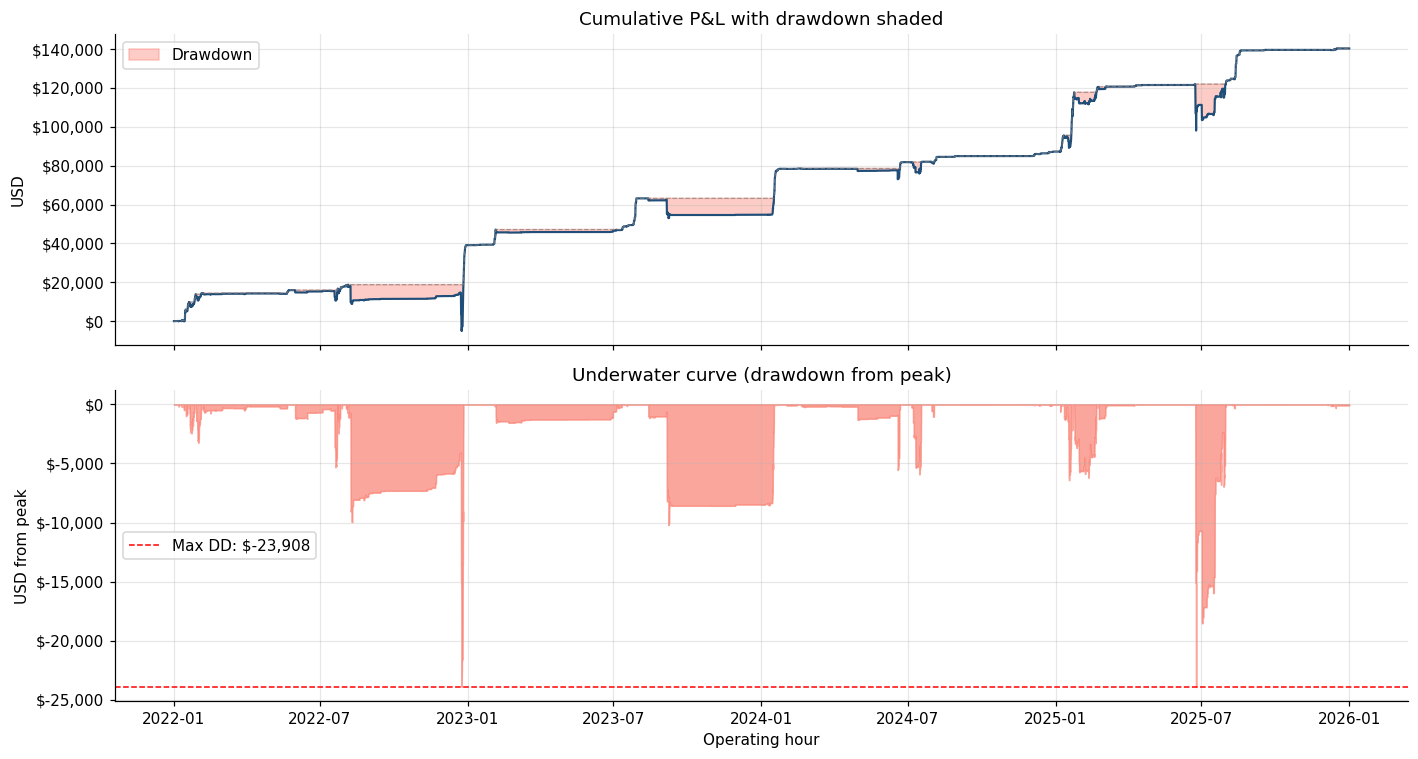

Maximum drawdown: $-23,907.65  at  2025-06-24 16:00:00-04:00
Total P&L at that point: $98,058.40


In [21]:
# ── Drawdown visualization ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax = axes[0]
ax.plot(cum.index, cum['pnl_total'], lw=1.4, color='#1f4e79')
ax.plot(cum.index, running_max,      lw=0.8, color='grey', ls='--', alpha=0.7)
ax.fill_between(cum.index, cum['pnl_total'], running_max,
                where=cum['pnl_total'] < running_max, color='salmon', alpha=0.4, label='Drawdown')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_title('Cumulative P&L with drawdown shaded')
ax.set_ylabel('USD'); ax.legend()

ax = axes[1]
ax.fill_between(drawdown.index, drawdown, 0, color='salmon', alpha=0.7)
ax.axhline(max_dd, color='red', lw=1, ls='--', label=f'Max DD: ${max_dd:,.0f}')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_title('Underwater curve (drawdown from peak)')
ax.set_ylabel('USD from peak'); ax.legend()
ax.set_xlabel('Operating hour')

plt.tight_layout()
plt.show()

dd_date = drawdown.idxmin()
print(f'Maximum drawdown: ${max_dd:,.2f}  at  {dd_date}')
print(f'Total P&L at that point: ${cum.loc[dd_date, "pnl_total"]:,.2f}')

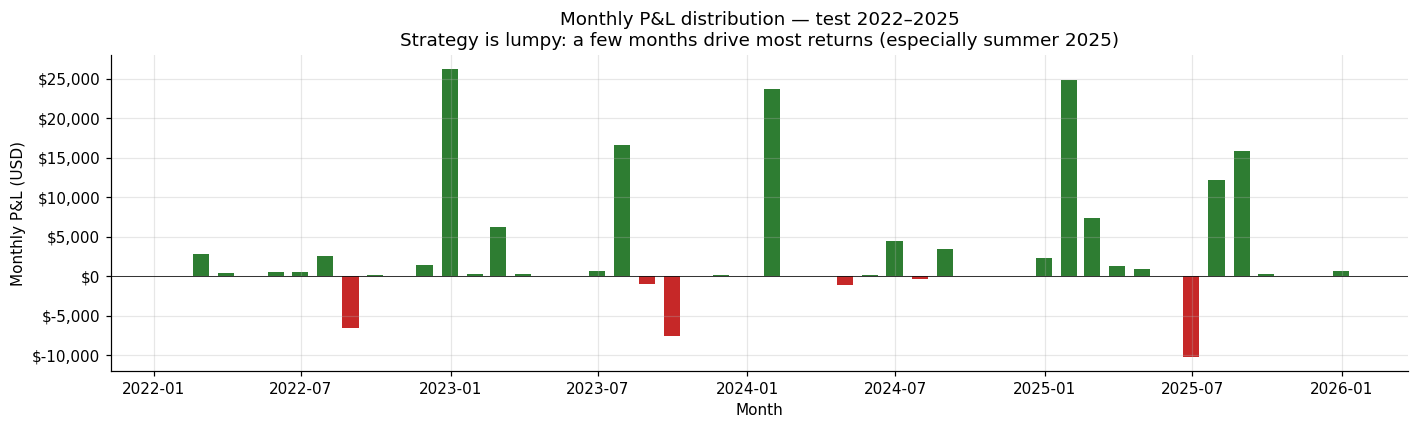

Best month:  2022-12   $26,199.24
Worst month: 2025-06   $-10,225.16
Positive months: 31 of 48


In [22]:
# ── Monthly P&L bar chart ──────────────────────────────────────────────────────
monthly_bars = monthly_pnl.copy()
colors = ['#2e7d32' if v >= 0 else '#c62828' for v in monthly_bars]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(monthly_bars.index, monthly_bars.values, color=colors, width=20)
ax.axhline(0, color='black', lw=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_xlabel('Month')
ax.set_ylabel('Monthly P&L (USD)')
ax.set_title('Monthly P&L distribution — test 2022–2025\n'
             'Strategy is lumpy: a few months drive most returns (especially summer 2025)')
plt.tight_layout()
plt.show()

print('Best month: ', monthly_bars.idxmax().strftime('%Y-%m'), f'  ${monthly_bars.max():,.2f}')
print('Worst month:', monthly_bars.idxmin().strftime('%Y-%m'), f'  ${monthly_bars.min():,.2f}')
print('Positive months:', (monthly_bars > 0).sum(), 'of', len(monthly_bars))

---
## 9. Where do we go from here?

The pipeline above implements the **unit-size benchmark strategy**.  
Two natural extensions can sharpen the results without changing the core approach.

---

### 9.1 Directional clipping — *ready to implement*

**Problem**: any cross-zone optimiser can place a DEC bid in a zone where the model  
predicted a negative DART (INC signal) — a self-contradicting position.

**Fix**: add a "clipping" rule — only execute trades whose *direction* matches the  
model's predicted DART sign. This trades some diversification for consistency and  
typically produces smoother equity curves.

Implementation: one extra column in the trades dataframe, one extra mask. No new data needed.

---

### 9.2 Statistically significant buckets — *ready to implement*

**Problem**: some (zone, side) combinations earn P&L only in specific regimes  
(e.g., LONGIL_neg in Summer Peak hours).

**Fix**: split the validation performance by (season × peak/off-peak) and only trade  
zone-season-band combinations where **t-statistic > 2 and n_trades ≥ 50**.

INC trades tend to concentrate almost entirely in Summer Peak LONGIL. Restricting to  
significant buckets reduces noise without sacrificing much signal.

---

### 9.3 Optimal sizing with market impact — *requires NYISO bid-stack data*

Instead of 1 MWh flat per signal, solve a quadratic optimisation:

$$\max_{q \in \mathbb{R}^Z} \quad x_t^\top q - k_E^+ S^2 - \sum_z k_z q_z^2, \quad S = \mathbf{1}^\top q$$

where $k_E^\pm$ are **energy impact coefficients** estimated from the day-ahead bid  
stack (the supply/demand curve NYISO actually clears against), and $k_z$ are  
**zone-specific congestion impact coefficients** (inversely proportional to zone load).

This is the path from unit-size results to multi-MWh production-scale P&L — optimal  
sizing concentrates positions in the highest-edge zone-hours.

**Data needed**: NYISO day-ahead supply/demand bid stacks (hourly). Available from  
NYISO OASIS but not in gridstatus — requires a custom downloader.

---

### Recommended next steps

| Step | Effort | Impact | Needs new data? |
|---|---|---|---|
| **Directional clipping** | 30 min | Smoother P&L curve | No |
| **Significant buckets** | 1-2 hr | Isolates the best regime-zone combos | No |
| **Coefficient interpretation** | 30 min | Explains *what* the model learned | No |
| **Optimal sizing** | 2-3 days | Scales from unit-size to multi-MWh | Yes (NYISO bid stacks) |